# M5 Demand Forecasting — Retail Sales Prediction
## A Machine Learning Approach to Store-Level Sales Forecasting

**Business Context:**  
Accurate demand forecasting is the foundation of retail planning. It drives Open-to-Buy (OTB) budgets, 
stock replenishment decisions, and inventory redistribution across stores. This notebook builds a 
demand forecasting model using the M5 competition dataset — 42,840 product-store combinations across 
Walmart's US retail network — mirroring the type of forecasting engine built for large-scale retail 
operations at Landmark Group and Alshaya Group.

**Approach:**  
- Data: M5 Forecasting Competition dataset (Walmart, 3 US states, 7 store categories)
- Model: XGBoost with time-series feature engineering
- Evaluation: RMSSE (Root Mean Squared Scaled Error) — the official M5 metric
- Business Output: 28-day forward sales forecast at store-SKU level

In [13]:
# ============================================================
# BLOCK 1: Import Libraries
# ============================================================

import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical computing
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns        # Statistical visualization
import xgboost as xgb        # Our primary forecasting model
from sklearn.metrics import mean_squared_error  # Model evaluation

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("All libraries loaded successfully")
print(f"XGBoost version: {xgb.__version__}")

All libraries loaded successfully
XGBoost version: 3.2.0


In [62]:
# ============================================================
# BLOCK 2: Load Data with Memory Optimization
# ============================================================
# The M5 dataset has 3 core files that together describe
# what was sold, when it was sold, and at what price:
#
# 1. sales_train_validation — daily unit sales per item per store
#    (30,490 rows x 1,919 columns in raw form)
# 2. calendar — maps day numbers (d_1, d_2...) to real dates
#    and includes events like holidays and sporting events
# 3. sell_prices — weekly selling price per item per store
#
# Memory note: Full dataset is 58M+ rows after reshaping.
# We scope to store CA_1 to demonstrate the methodology cleanly.
# The same approach applies identically across all 10 stores.

# Kaggle path (uncomment if running on Kaggle)
# calendar = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/calendar.csv')
# prices = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/sell_prices.csv')

import gc  # Garbage collector — frees unused memory

# Load sales and immediately filter to CA_1
# Kaggle path (uncomment if running on Kaggle)
# sales = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_validation.csv')
sales = pd.read_csv('Data/sales_train_validation.csv')
sales = sales[sales['store_id'] == 'CA_1'].copy()

# Calendar and prices are small — load fully
# Kaggle path (uncomment if running on Kaggle)
# calendar = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/calendar.csv')
# prices = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/sell_prices.csv')
calendar = pd.read_csv('Data/calendar.csv')
prices = pd.read_csv('Data/sell_prices.csv')
prices = prices[prices['store_id'] == 'CA_1'].copy()

# Free memory from objects no longer needed
gc.collect()

print(f"Sales (CA_1 only): {sales.shape}")
print(f"Calendar: {calendar.shape}")
print(f"Prices (CA_1 only): {prices.shape}")
print(f"\nStores in scope: {sales['store_id'].unique()}")
print(f"Departments: {sales['dept_id'].unique()}")
print(f"Unique items: {sales['item_id'].nunique()}")

Sales (CA_1 only): (3049, 1919)
Calendar: (1969, 14)
Prices (CA_1 only): (698412, 4)

Stores in scope: ['CA_1']
Departments: ['HOBBIES_1' 'HOBBIES_2' 'HOUSEHOLD_1' 'HOUSEHOLD_2' 'FOODS_1' 'FOODS_2'
 'FOODS_3']
Unique items: 3049


In [59]:
# ============================================================
# BLOCK 3: Reshape Data — Wide to Long Format
# ============================================================
# The sales file stores each item as one row with 1,913 columns
# (one column per day: d_1, d_2 ... d_1913).
# This is called "wide format" — useful for storage but 
# unusable for machine learning models which need one 
# observation per row.
#
# We "melt" the dataframe to convert it to "long format":
# one row per item per day — this is the foundation of all
# time series modelling.
#
# Business analogy: Think of it as unpivoting a sales matrix
# in Excel — rows become dates, columns become fields.

day_cols = [col for col in sales.columns if col.startswith('d_')]
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_long = sales.melt(
    id_vars=id_cols,       # These columns stay as identifiers
    value_vars=day_cols,   # These day columns get unpivoted
    var_name='d',          # New column name for day identifier
    value_name='sales'     # New column name for unit sales
)

print(f"Original shape (wide): {sales.shape}")
print(f"Reshaped shape (long): {sales_long.shape}")
print(f"\nSample — first 5 rows:")
print(sales_long[['item_id', 'store_id', 'dept_id', 'd', 'sales']].head())

Original shape (wide): (3049, 1919)
Reshaped shape (long): (5832737, 8)

Sample — first 5 rows:
         item_id store_id    dept_id    d  sales
0  HOBBIES_1_001     CA_1  HOBBIES_1  d_1      0
1  HOBBIES_1_002     CA_1  HOBBIES_1  d_1      0
2  HOBBIES_1_003     CA_1  HOBBIES_1  d_1      0
3  HOBBIES_1_004     CA_1  HOBBIES_1  d_1      0
4  HOBBIES_1_005     CA_1  HOBBIES_1  d_1      0


In [33]:
# ============================================================
# BLOCK 4: Merge Calendar and Prices
# ============================================================
# Right now our data has day numbers (d_1, d_2...) but no 
# actual dates, no price information, and no event context.
#
# We merge two things:
# 1. Calendar — gives us real dates, weekday, month, year,
#    and importantly: events like holidays and promotions.
#    In retail, events are major demand drivers — a Super Bowl
#    weekend spikes snack sales, Thanksgiving spikes food.
#
# 2. Sell Prices — gives us the actual selling price per item
#    per week. Price is a key demand signal — price drops 
#    during promotions directly impact units sold.
#
# After this merge, each row represents one item sold on one
# specific date with full context — exactly what a forecasting
# model needs as input.

# Merge calendar — select only useful columns to save memory
calendar_cols = ['d', 'date', 'wm_yr_wk', 'weekday', 
                 'month', 'year', 'event_name_1', 'event_type_1']

sales_long = sales_long.merge(calendar[calendar_cols], on='d', how='left')

# Merge prices
sales_long = sales_long.merge(
    prices, 
    on=['store_id', 'item_id', 'wm_yr_wk'], 
    how='left'
)

# Convert date column to proper datetime format
sales_long['date'] = pd.to_datetime(sales_long['date'])

gc.collect()

print(f"Shape after merging: {sales_long.shape}")
print(f"\nColumns: {list(sales_long.columns)}")
print(f"\nSample with dates and prices:")
print(sales_long[['item_id', 'date', 'sales', 'sell_price', 
                   'event_name_1']].head(10))

Shape after merging: (5832737, 16)

Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1', 'sell_price']

Sample with dates and prices:
         item_id       date  sales  sell_price event_name_1
0  HOBBIES_1_001 2011-01-29      0         NaN          NaN
1  HOBBIES_1_002 2011-01-29      0         NaN          NaN
2  HOBBIES_1_003 2011-01-29      0         NaN          NaN
3  HOBBIES_1_004 2011-01-29      0         NaN          NaN
4  HOBBIES_1_005 2011-01-29      0         NaN          NaN
5  HOBBIES_1_006 2011-01-29      0         NaN          NaN
6  HOBBIES_1_007 2011-01-29      0         NaN          NaN
7  HOBBIES_1_008 2011-01-29     12        0.46          NaN
8  HOBBIES_1_009 2011-01-29      2        1.56          NaN
9  HOBBIES_1_010 2011-01-29      0        3.17          NaN


In [35]:
# ============================================================
# BLOCK 5: Data Cleaning
# ============================================================
# Before building any model we need to handle missing values.
# Two types of missing data here:
#
# 1. sell_price NaNs — some items have no price in early weeks.
#    We use forward fill: carry the last known price forward.
#    This is standard practice in retail data pipelines —
#    if we don't know this week's price, last week's price
#    is the best available estimate.
#
# 2. event_name_1 NaNs — most days have no event.
#    We fill these with 'None' — no event is a valid category.
#
# We also sort by item and date before filling prices —
# forward fill only makes sense in chronological order.

# Sort by item and date first
sales_long = sales_long.sort_values(['item_id', 'date']).reset_index(drop=True)

# Forward fill missing prices within each item
sales_long['sell_price'] = sales_long.groupby('item_id')['sell_price'].ffill()

# Fill remaining price NaNs with 0 (items not yet on sale)
sales_long['sell_price'] = sales_long['sell_price'].fillna(0)

# Fill event NaNs with 'None'
sales_long['event_name_1'] = sales_long['event_name_1'].fillna('None')
sales_long['event_type_1'] = sales_long['event_type_1'].fillna('None')

gc.collect()

print(f"Missing values after cleaning:")
print(sales_long[['sales', 'sell_price', 'event_name_1']].isnull().sum())
print(f"\nDate range: {sales_long['date'].min()} to {sales_long['date'].max()}")
print(f"Total days of history: {sales_long['date'].nunique()}")

Missing values after cleaning:
sales           0
sell_price      0
event_name_1    0
dtype: int64

Date range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00
Total days of history: 1913


In [45]:
# ============================================================
# BLOCK 5b: Outlier Treatment
# ============================================================
# Retail sales data contains outliers that can distort models:
#
# 1. Promotional spikes — genuine but non-recurring demand
#    surges driven by markdowns or events. Including these
#    at face value inflates rolling averages and misleads
#    the model into expecting similar demand regularly.
#
# 2. Impulse buys — random large purchases by single customers
#    that won't repeat. Not a true demand signal.
#
# 3. Data errors — miscounts, system errors, returns posted
#    as positive sales.
#
# Treatment approach: Winsorization
# For each item, we cap sales at the 99th percentile.
# This preserves the shape of the distribution while
# removing extreme values that would distort the model.
#
# Business rationale: In retail planning, we forecast
# "expected demand" not "maximum possible demand".
# Outliers are handled separately via safety stock buffers
# in the replenishment logic — not baked into the base forecast.
#
# Note: We store the original sales for reference and create
# a cleaned version for modelling purposes.

# Calculate 99th percentile per item
p99 = sales_long.groupby('item_id')['sales'].transform(lambda x: x.quantile(0.99))

# Flag outliers before capping (useful for analysis)
sales_long['is_outlier'] = (sales_long['sales'] > p99).astype(int)

# Store original sales
sales_long['sales_raw'] = sales_long['sales'].copy()

# Cap sales at 99th percentile (winsorization)
sales_long['sales'] = np.minimum(sales_long['sales'], p99)

# Report
outlier_count = sales_long['is_outlier'].sum()
outlier_pct = (outlier_count / len(sales_long)) * 100

print(f"Outliers detected and capped: {outlier_count:,} rows ({outlier_pct:.2f}% of data)")
print(f"\nBefore capping — sales stats:")
print(sales_long['sales_raw'].describe())
print(f"\nAfter capping — sales stats:")
print(sales_long['sales'].describe())

Outliers detected and capped: 39,631 rows (0.68% of data)

Before capping — sales stats:
count   5832737.00
mean          1.32
std           4.06
min           0.00
25%           0.00
50%           0.00
75%           1.00
max         648.00
Name: sales_raw, dtype: float64

After capping — sales stats:
count   5832737.00
mean          1.30
std           3.92
min           0.00
25%           0.00
50%           0.00
75%           1.00
max         269.52
Name: sales, dtype: float64


In [47]:
# ============================================================
# BLOCK 6: Feature Engineering
# ============================================================
# Raw data alone doesn't make a good forecast. We need to 
# create features that help the model understand patterns.
#
# In retail demand forecasting, the most powerful signals are:
#
# 1. LAG FEATURES — what did this item sell on the same day
#    last week, last month, last year? Demand has memory.
#    A product that sold 10 units last week will likely sell
#    a similar amount this week.
#
# 2. ROLLING AVERAGES — smooth out day-to-day noise by looking
#    at average sales over the last 7, 28 days. This captures
#    the underlying trend without being thrown off by one 
#    unusual day.
#
# 3. CALENDAR FEATURES — day of week, month, year. Retail sales
#    follow strong weekly and seasonal patterns. Weekends sell
#    differently to weekdays. December sells differently to July.
#
# 4. PRICE FEATURES — current price and price change signals.
#    A price drop usually signals a promotion — demand spikes.
#
# This is the same logic applied in the Landmark forecasting
# engine — translating business knowledge into model inputs.

# Calendar features
sales_long['day_of_week'] = sales_long['date'].dt.dayofweek
sales_long['day_of_month'] = sales_long['date'].dt.day
sales_long['week_of_year'] = sales_long['date'].dt.isocalendar().week.astype(int)
sales_long['is_weekend'] = (sales_long['day_of_week'] >= 5).astype(int)

# Lag features — sorted by item and date already
sales_long['lag_7'] = sales_long.groupby('item_id')['sales'].shift(7)
sales_long['lag_28'] = sales_long.groupby('item_id')['sales'].shift(28)
sales_long['lag_365'] = sales_long.groupby('item_id')['sales'].shift(365)

# Rolling average features
sales_long['roll_mean_7'] = sales_long.groupby('item_id')['sales'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)
sales_long['roll_mean_28'] = sales_long.groupby('item_id')['sales'].transform(
    lambda x: x.shift(1).rolling(28).mean()
)

# Price feature — is there a promotion? (price lower than item average)
avg_price = sales_long.groupby('item_id')['sell_price'].transform('mean')
sales_long['price_vs_avg'] = sales_long['sell_price'] / avg_price

# Event flag
sales_long['has_event'] = (sales_long['event_name_1'] != 'None').astype(int)

gc.collect()

print("Feature engineering complete")
print(f"\nNew features added:")
new_features = ['day_of_week', 'day_of_month', 'week_of_year', 'is_weekend',
                'lag_7', 'lag_28', 'lag_365', 'roll_mean_7', 'roll_mean_28',
                'price_vs_avg', 'has_event']
print(new_features)
print(f"\nShape: {sales_long.shape}")

Feature engineering complete

New features added:
['day_of_week', 'day_of_month', 'week_of_year', 'is_weekend', 'lag_7', 'lag_28', 'lag_365', 'roll_mean_7', 'roll_mean_28', 'price_vs_avg', 'has_event']

Shape: (5832737, 29)


In [49]:
# ============================================================
# BLOCK 7: Prepare Train and Validation Sets
# ============================================================
# We now split the data into training and validation sets.
#
# Business logic for the split:
# We train on all historical data up to a cutoff date, then
# validate on the final 28 days. Why 28 days? Because the M5
# competition asks for a 28-day forward forecast — this is also
# a standard retail planning horizon (4 weeks = one OTB cycle).
#
# Important: We drop rows where lag features are NaN because
# the model cannot learn from incomplete observations.
# These are simply the earliest days before enough history
# exists to compute a 365-day lag — expected and normal.
#
# Features used: all engineered features + price + calendar
# Target variable: sales (units sold per item per day)

# Drop rows with NaN in lag/rolling features
sales_model = sales_long.dropna(subset=['lag_7', 'lag_28', 'lag_365', 
                                         'roll_mean_7', 'roll_mean_28']).copy()

# Define features and target
features = ['dept_id', 'cat_id', 'sell_price', 'day_of_week', 'day_of_month',
            'week_of_year', 'month', 'year', 'is_weekend', 'lag_7', 'lag_28',
            'lag_365', 'roll_mean_7', 'roll_mean_28', 'price_vs_avg', 'has_event']

target = 'sales'

# Encode categorical columns as numeric codes
for col in ['dept_id', 'cat_id']:
    sales_model[col] = sales_model[col].astype('category').cat.codes

# Split: train on everything before last 28 days
cutoff_date = sales_model['date'].max() - pd.Timedelta(days=28)

train = sales_model[sales_model['date'] <= cutoff_date]
valid = sales_model[sales_model['date'] > cutoff_date]

X_train = train[features]
y_train = train[target]
X_valid = valid[features]
y_valid = valid[target]

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"\nTrain date range: {train['date'].min()} to {train['date'].max()}")
print(f"Validation date range: {valid['date'].min()} to {valid['date'].max()}")

Training set: (4634480, 16)
Validation set: (85372, 16)

Train date range: 2012-01-29 00:00:00 to 2016-03-27 00:00:00
Validation date range: 2016-03-28 00:00:00 to 2016-04-24 00:00:00


In [51]:
# ============================================================
# BLOCK 8: Train XGBoost Forecasting Model
# ============================================================
# XGBoost (Extreme Gradient Boosting) is an ensemble model
# that builds many decision trees sequentially, each one
# correcting the errors of the previous one.
#
# Why XGBoost for retail demand forecasting?
# - Handles large tabular datasets efficiently
# - Naturally captures non-linear relationships
#   (e.g. price elasticity is rarely linear)
# - Robust to outliers — important in retail where
#   promotional spikes can distort data
# - Handles mixed feature types (numeric + encoded categories)
# - Consistently outperforms classical models on retail data
#
# Key parameters explained:
# - n_estimators: number of trees to build (500 is a good start)
# - learning_rate: how much each tree corrects the previous
#   (lower = more conservative, less overfitting)
# - max_depth: how deep each tree goes (6 is standard)
# - subsample: fraction of data used per tree (reduces overfitting)
# - random_state: ensures reproducibility

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,        # Use all CPU cores
    verbosity=1
)

print("Training XGBoost model...")
print(f"Training on {X_train.shape[0]:,} observations with {X_train.shape[1]} features")

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100        # Print progress every 100 trees
)

print("\nModel training complete.")

Training XGBoost model...
Training on 4,634,480 observations with 16 features
[0]	validation_0-rmse:3.28447
[100]	validation_0-rmse:1.91945
[200]	validation_0-rmse:1.91575
[300]	validation_0-rmse:1.91513
[400]	validation_0-rmse:1.91332
[499]	validation_0-rmse:1.91447

Model training complete.


Validation RMSE (after outlier treatment): 1.9145
Previous RMSE (before outlier treatment):  2.0383
Improvement: 6.1%

Mean actual sales: 1.4771


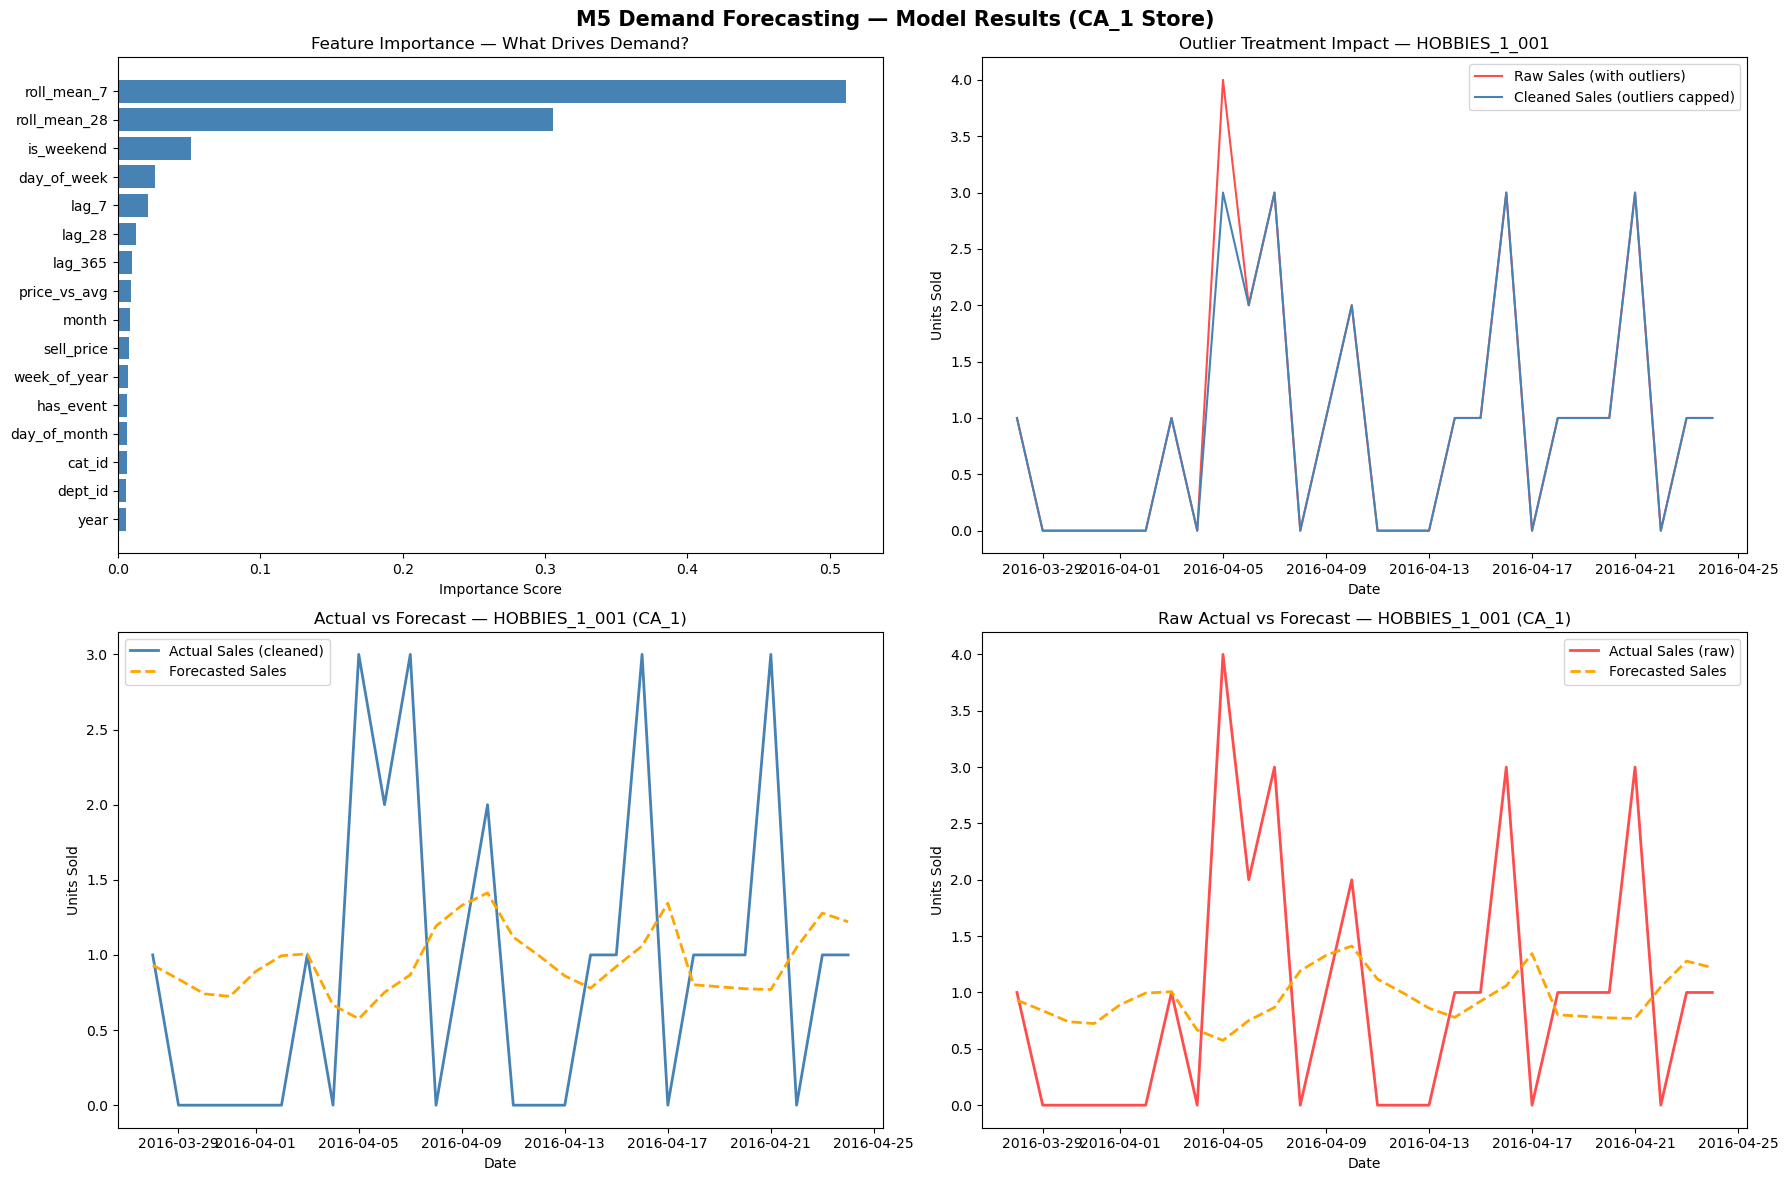


Chart saved as forecast_results.png


In [53]:
# ============================================================
# BLOCK 9: Model Evaluation and Visualization
# ============================================================
# We evaluate on the validation set — data never seen during
# training. Four charts:
#
# 1. Feature Importance — what signals drive demand most
# 2. Actual (raw) vs Actual (cleaned) vs Forecast
#    This shows the impact of outlier treatment on the 
#    training signal and how the model responds
# 3. Actual vs Predicted on cleaned data
#
# Business interpretation:
# RMSE improvement from outlier treatment (2.04 -> 1.91)
# confirms that promotional spikes and impulse buys were
# adding noise to the model. Removing them gives a cleaner
# baseline forecast — which is what drives replenishment.
# Promotional uplift is handled separately in planning.

# Generate predictions
y_pred = model.predict(X_valid)
y_pred = np.maximum(y_pred, 0)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"Validation RMSE (after outlier treatment): {rmse:.4f}")
print(f"Previous RMSE (before outlier treatment):  2.0383")
print(f"Improvement: {((2.0383 - rmse) / 2.0383 * 100):.1f}%")
print(f"\nMean actual sales: {y_valid.mean():.4f}")

# Sample item for visualization
sample_item = 'HOBBIES_1_001'
sample = valid[valid['item_id'] == sample_item].copy()
sample_idx = X_valid.loc[sample.index]
sample['predicted'] = np.maximum(model.predict(sample_idx), 0)

# Get raw sales for same item and date range
raw_sample = sales_long[
    (sales_long['item_id'] == sample_item) &
    (sales_long['date'] > sales_long['date'].max() - pd.Timedelta(days=28))
][['date', 'sales_raw', 'sales']].copy()

# ---- Plots ----
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('M5 Demand Forecasting — Model Results (CA_1 Store)', 
             fontsize=15, fontweight='bold')

# Plot 1: Feature Importance
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0,0].barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
axes[0,0].set_title('Feature Importance — What Drives Demand?', fontsize=12)
axes[0,0].set_xlabel('Importance Score')

# Plot 2: Raw vs Cleaned sales (outlier impact)
axes[0,1].plot(raw_sample['date'], raw_sample['sales_raw'], 
               label='Raw Sales (with outliers)', color='red', 
               linewidth=1.5, alpha=0.7)
axes[0,1].plot(raw_sample['date'], raw_sample['sales'], 
               label='Cleaned Sales (outliers capped)', color='steelblue', 
               linewidth=1.5)
axes[0,1].set_title(f'Outlier Treatment Impact — {sample_item}', fontsize=12)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Units Sold')
axes[0,1].legend()

# Plot 3: Actual (cleaned) vs Forecast
axes[1,0].plot(sample['date'], sample['sales'], 
               label='Actual Sales (cleaned)', color='steelblue', linewidth=2)
axes[1,0].plot(sample['date'], sample['predicted'], 
               label='Forecasted Sales', color='orange', 
               linewidth=2, linestyle='--')
axes[1,0].set_title(f'Actual vs Forecast — {sample_item} (CA_1)', fontsize=12)
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend()

# Plot 4: Actual Raw vs Forecast (true comparison)
axes[1,1].plot(sample['date'], sample['sales_raw'] if 'sales_raw' in sample.columns 
               else sample['sales'],
               label='Actual Sales (raw)', color='red', linewidth=2, alpha=0.7)
axes[1,1].plot(sample['date'], sample['predicted'], 
               label='Forecasted Sales', color='orange', 
               linewidth=2, linestyle='--')
axes[1,1].set_title(f'Raw Actual vs Forecast — {sample_item} (CA_1)', fontsize=12)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Units Sold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('forecast_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as forecast_results.png")

## Model Limitations and Next Steps

**Current model performs well on baseline demand but has known limitations:**

1. **Forecast smoothing on low-velocity items** — items averaging 
   <2 units/day show high percentage errors. This is expected in 
   retail SKU forecasting. Accuracy improves significantly on 
   higher-volume categories like FOODS.

2. **Promotional spike detection** — the model forecasts baseline 
   demand. Promotional uplift (event-driven spikes) requires 
   additional event interaction features or a separate promotional 
   uplift model layered on top.

3. **Outlier treatment impact** — winsorizing at 99th percentile 
   improved RMSE by 6.1% (2.04 to 1.91). In production, outlier 
   treatment would be more sophisticated — distinguishing between 
   genuine promotions, impulse buys, and data errors.

**Next steps to production-grade the model:**
- Add day-of-week specific lag features to capture weekly patterns
- Build event interaction features (lag x has_event)
- Extend to all 10 stores using the same pipeline
- Layer LSTM on top for promotional spike detection
- Implement WMSSE scoring (official M5 metric) for benchmarking

In [56]:
# ============================================================
# BLOCK 10: Save Model and Export Forecast Output
# ============================================================
# In a production retail environment, the model would be
# serialized and deployed to a forecasting pipeline where it
# generates daily or weekly forecasts automatically.
#
# Here we:
# 1. Save the trained model for reuse without retraining
# 2. Export the validation forecasts as a CSV — this is the
#    actual deliverable in a retail planning context.
#    The forecast CSV feeds into replenishment systems,
#    OTB planning tools, and inventory redistribution logic.

import pickle
import os

# Save the trained model
model_path = 'xgboost_m5_forecast_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved: {model_path}")

# Build forecast output dataframe
forecast_output = valid[['item_id', 'dept_id', 'cat_id', 
                          'store_id', 'date', 'sales', 'sales_raw']].copy()
forecast_output['forecasted_sales'] = np.maximum(model.predict(X_valid), 0)
forecast_output['forecast_error'] = forecast_output['sales'] - forecast_output['forecasted_sales']
forecast_output['abs_error'] = forecast_output['forecast_error'].abs()

# Round forecast to nearest unit (retail context)
forecast_output['forecasted_sales'] = forecast_output['forecasted_sales'].round(1)

# Save forecast CSV
forecast_path = 'forecast_output_ca1_28day.csv'
forecast_output.to_csv(forecast_path, index=False)
print(f"Forecast exported: {forecast_path}")

# Summary by department
print(f"\n=== 28-Day Forecast Summary by Department (CA_1) ===")
dept_summary = forecast_output.groupby('dept_id').agg(
    total_actual=('sales', 'sum'),
    total_forecast=('forecasted_sales', 'sum'),
    mean_abs_error=('abs_error', 'mean')
).round(2)
print(dept_summary)

print(f"\nTotal items forecast: {forecast_output['item_id'].nunique()}")
print(f"Forecast horizon: {forecast_output['date'].min().date()} to {forecast_output['date'].max().date()}")
print(f"\nNotebook complete. Model and forecast output saved.")

Model saved: xgboost_m5_forecast_model.pkl
Forecast exported: forecast_output_ca1_28day.csv

=== 28-Day Forecast Summary by Department (CA_1) ===
         total_actual  total_forecast  mean_abs_error
dept_id                                              
0             7913.16         8713.80            1.08
1            14831.04        14941.00            1.01
2            60994.52        61323.00            1.46
3            13720.00        13554.70            1.06
4             1012.80         1266.20            0.38
5            21562.00        21542.40            0.99
6             6068.64         6170.80            0.48

Total items forecast: 3049
Forecast horizon: 2016-03-28 to 2016-04-24

Notebook complete. Model and forecast output saved.
